In [3]:
import os
import sys
import json
import glob
import pickle
import datetime
import pandas as pd
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import scipy as sp

sys.path.insert(1, './utils')
from utils import *
from plotUtils import *
from mUtils import *

%matplotlib inline
plt.rcParams.update({'font.size': 18})

In [4]:
# read parameters from a json file
with open('./params.json', 'r+') as f:
    params = json.load(f)

In [5]:
def smooth(y, nWindow, polyOrder=2):
    y_smooth = sp.signal.savgol_filter(y, nWindow, polyOrder, mode='nearest')
    return y_smooth

In [7]:
root_dir = './system_01/results'
type_dir = 'fp'
load_str = datetime.datetime(2023, 12, 15)

load_dir = os.path.join(root_dir, type_dir, f'exp-{load_str.year}-{load_str.month}-{load_str.day}')
file_name = f'{scene_dir}_data_final.pkl'

In [8]:
save_dir = os.path.join(root_dir, "thesis", type_dir)
os.makedirs(save_dir, exist_ok=True)

In [9]:
with open(os.path.join(load_dir, file_name), 'rb') as file_:
    fp_data = pickle.load(file_)

fp_df = pd.DataFrame.from_dict(fp_data)
fp_df = fp_df.sort_values(by = ['I', 'K', 'sigma'], ascending = [True, True, True])

In [10]:
I_uniq = fp_df['I'].unique()
sigma_uniq = fp_df['sigma'].unique()
K_uniq = fp_df['K'].unique()

nIvals = len(I_uniq)
nSigvals = len(sigma_uniq)
nKvals = len(K_uniq)

print(f"Unique I's = {nIvals} | sigma's = {nSigvals} | K's = {nKvals}")

Unique I's = 51 | sigma's = 50 | K's = 51


In [11]:
## Calculate the multi-stability region as delta K vs. sigma for different I values

deltaK_arr = np.zeros((nIvals, nSigvals))   # region width in terms of K
MultiK = np.zeros((nIvals, nSigvals))       # no. of multi-stability regions

for nI in range (0, nIvals):
    I = I_uniq[nI]

    if nI % 10 == 0:
        print(f'Ealuating multi-region width for I = {I:.3f}')
    for nS, sigma_ in enumerate(sigma_uniq):
        
        df_sub = fp_df[(fp_df['sigma'] == sigma_) & (fp_df['I'] == I)]

        fp_counts_dict = df_sub['K'].value_counts().sort_index().to_dict()

        K = np.array(list(fp_counts_dict.keys()))
        Ksort = np.argsort(K)
        K = K[Ksort]

        FP_count = np.array(list(fp_counts_dict.values()))
        FP_count = FP_count[Ksort]

        MultiR_id = np.where(FP_count > 1)[0]

        if len(MultiR_id) == 0:
            continue

        Mult_diffid = np.diff(MultiR_id)

        markers = np.where(Mult_diffid > 5)[0] + 1
        nRegions = len(markers)

        # if there are multiple multi-stable regions in the system delta K is claculated as sum of delta K over all regions
        if nRegions:
            segment_delt = []
            start_marker = 0

            for i in range(nRegions + 1):
                if i !=  nRegions:
                    marker = markers[i]
                    segment = MultiR_id[start_marker:marker]
                else:
                    segment = MultiR_id[start_marker:]
                
                if i < nRegions:
                    start_marker = marker

                segment_delt.append(K[segment[-1]] - K[segment[0]]) if len(segment) > 0 else 0
            
            deltaK_arr[nI, nS] = sum(segment_delt)
            MultiK[nI, nS] = len(segment_delt)

        else:
            MultiK[nI, nS] += 1
            deltaK_arr[nI, nS] = K[MultiR_id[-1]] - K[MultiR_id[0]]       

Ealuating multi-region width for I = -15.625
Ealuating multi-region width for I = -9.375
Ealuating multi-region width for I = -3.125
Ealuating multi-region width for I = 3.125
Ealuating multi-region width for I = 9.375
Ealuating multi-region width for I = 15.625


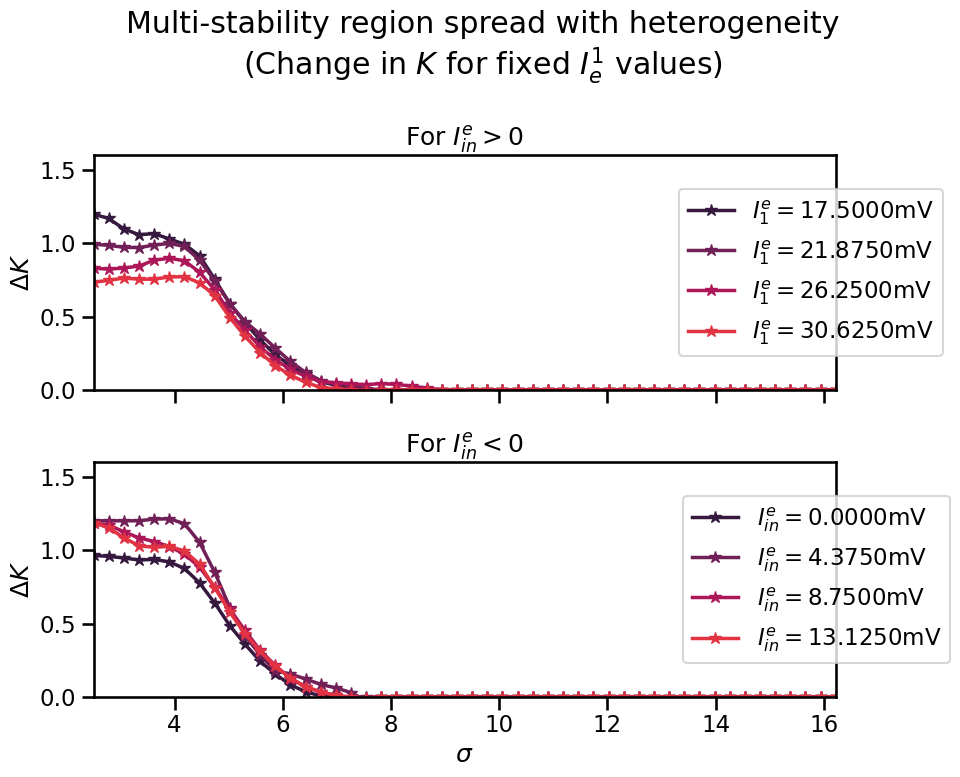

In [12]:
fileName = 'Scene01_MultiStable_DeltaK.png'

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(10, 8))

for nI in range(0, nIvals, 7):
    if I_uniq[nI] < 0:
        continue
    # axs[0].plot(sigma_uniq, deltaK_arr[nI, :], 'k--', linewidth=2.2, label=r"$I_{in}^e = $" + f"{I_uniq[nI]:.2f}mV")
    axs[0].plot(sigma_uniq, smooth(deltaK_arr[nI, :], 7, 3), '-*', linewidth=2.5, label=r"$I_{1}^e = $" + f"{I_uniq[nI] - params['i_e2']:.4f}mV")
    

axs[0].set_xlim(sigma_uniq[0], sigma_uniq[-1])
axs[0].set_ylim(0, max(deltaK_arr.flatten()))
axs[0].set_ylabel(r"$\Delta K$")
axs[0].legend(loc = 'center right', bbox_to_anchor=(1.16, 0.5))
axs[0].set_title(r"For $I_{in}^e > 0$")

for nI in range(0, nIvals, 7):
    if I_uniq[nI] > 0:
        continue
    # axs[1].plot(sigma_uniq, deltaK_arr[nI, :], 'k--', linewidth=2.2, label=r"$I_{in}^e = $" + f"{I_uniq[nI]:.2f}mV")
    axs[1].plot(sigma_uniq, smooth(deltaK_arr[nI, :], 7, 3), '-*', linewidth=2.5, label=r"$I_{in}^e = $" + f"{I_uniq[nI] - params['i_e2']:.4f}mV")

axs[1].set_xlim(sigma_uniq[0], sigma_uniq[-1])
axs[1].set_ylim(0, max(deltaK_arr.flatten()))
axs[1].set_xlabel(r"$\sigma$")
axs[1].set_ylabel(r"$\Delta K$")
axs[1].legend(loc = 'center right', bbox_to_anchor=(1.17, 0.5))
axs[1].set_title(r"For $I_{in}^e < 0$")


fig.suptitle("Multi-stability region spread with heterogeneity\n" + r"(Change in $K$ for fixed $I^1_e$ values)")
plt.tight_layout()

plt.savefig(os.path.join(save_dir, fileName), dpi=600, bbox_inches='tight')
plt.show()

Text(0.5, 1.0, 'Multi-stability region spread with heterogeneity \n(# of Multi-stable regions for fixed $I_{in}^e$ values)')

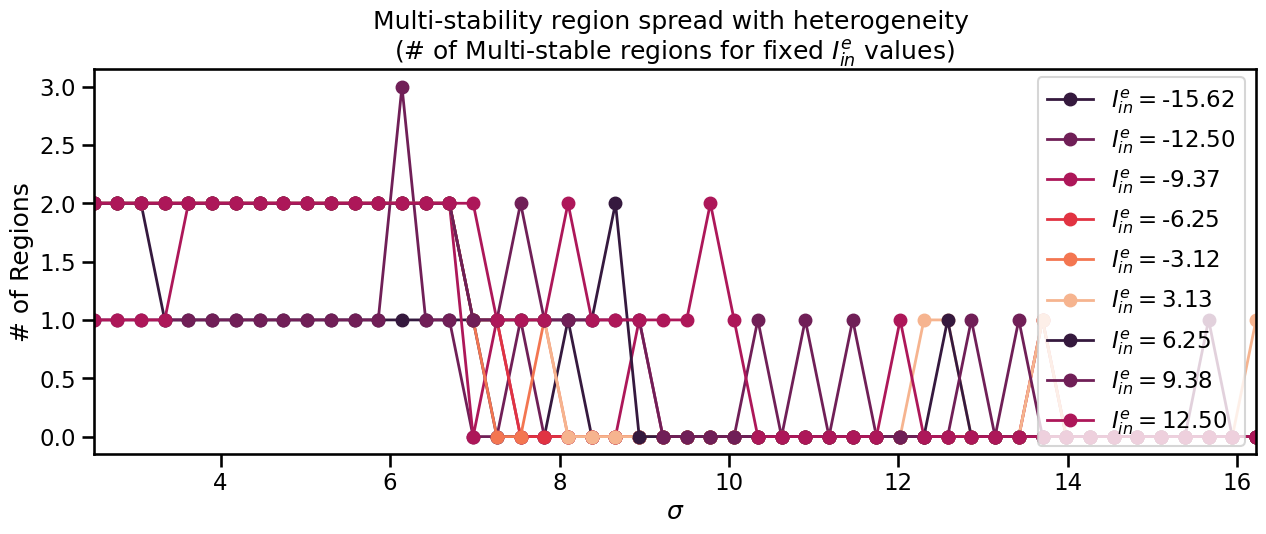

In [13]:
plt.figure(figsize=(15, 5))

for nI in range(0, nIvals - 1, 5):
    if round(I_uniq[nI], 2) == 0:
        continue
    plt.plot(sigma_uniq, MultiK[nI, :], '-o', linewidth=2.0, label=r"$I_{in}^e = $" + f"{I_uniq[nI]:.2f}")

plt.xlim(sigma_uniq[0], sigma_uniq[-1])
plt.xlabel(r"$\sigma$")
plt.ylabel(r"# of Regions")
plt.legend(loc='center right')
plt.title("Multi-stability region spread with heterogeneity \n" +\
          r"(# of Multi-stable regions for fixed $I_{in}^e$ values)")

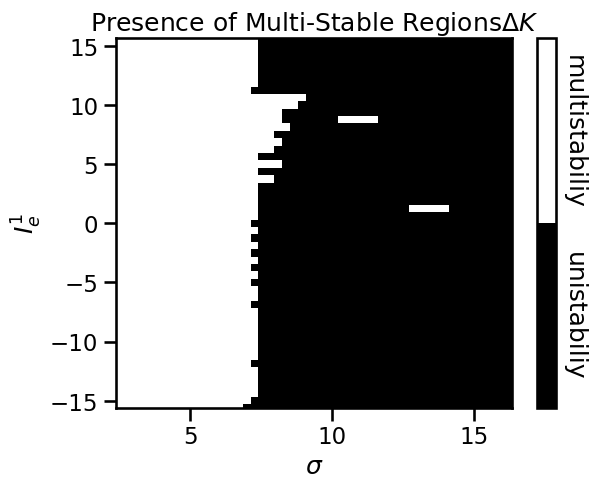

In [14]:
fileName = 'Scene01_MultiStable_DeltaK_HeatMap.png'

smoothDeltK = deepcopy(deltaK_arr)
cMap = ListedColormap(["black", "white"])

for nK in range(nKvals):
    smoothDeltK[nK, :] = smooth(smoothDeltK[nK, :], nWindow=7, polyOrder=3)

encodeDeltaK = deepcopy(smoothDeltK)
encodeDeltaK[encodeDeltaK > 0.000] = 1
encodeDeltaK[encodeDeltaK <= 0.000] = 0

heatmap = plt.pcolormesh(sigma_uniq, I_uniq, encodeDeltaK, cmap=cMap)
cbar = plt.colorbar(heatmap)

cbar.ax.get_yaxis().set_ticks([])
cbar.ax.text(2, .25 , r"unistabiliy", rotation=270, ha='center', va='center')
cbar.ax.text(2, .75 , r"multistabiliy", rotation=270, ha='center', va='center')
plt.xlabel(r"$\sigma$")
plt.ylabel(r"$I^1_e$"); plt.ylim(I_uniq[0], I_uniq[-1])
plt.title("Presence of Multi-Stable Regions" + r"$\Delta K$")

plt.savefig(os.path.join(save_dir, fileName), dpi=600, bbox_inches='tight')

In [15]:
deltaI_arr = np.zeros((nKvals, nSigvals))
MultiI = np.zeros((nKvals, nSigvals))

for nK, K in enumerate(K_uniq):
    if nK % 10 == 0:
        print(f'Ealuating multi-region width for K = {K:.3f}')
    for nS, sigma_ in enumerate(sigma_uniq):
        
        df_sub = fp_df[(fp_df['sigma'] == sigma_) & (fp_df['K'] == K)]

        fp_counts_dict = df_sub['I'].value_counts().sort_index().to_dict()

        I = np.array(list(fp_counts_dict.keys()))
        Isort = np.argsort(I)
        I = I[Isort]

        FP_count = np.array(list(fp_counts_dict.values()))
        FP_count = FP_count[Isort]

        MultiR_id = np.where(FP_count > 1)[0]

        if len(MultiR_id) == 0:
            continue

        Mult_diffid = np.diff(MultiR_id)

        markers = np.where(Mult_diffid > 4)[0] + 1
        nRegions = len(markers)

        if nRegions:
            segment_delt = []
            start_marker = 0

            for i in range(nRegions + 1):
                if i !=  nRegions:
                    marker = markers[i]
                    segment = MultiR_id[start_marker:marker]
                else:
                    segment = MultiR_id[start_marker:]
                
                if i < nRegions:
                    start_marker = marker

                segment_delt.append(I[segment[-1]] - I[segment[0]]) if len(segment) > 0 else 0

            deltaI_arr[nK, nS] = max(segment_delt)
            MultiI[nK, nS] = len(segment_delt)

        else:
            MultiI[nK, nS] += 1
            deltaI_arr[nK, nS] = I[MultiR_id[-1]] - I[MultiR_id[0]]

Ealuating multi-region width for K = -1.000
Ealuating multi-region width for K = -0.600
Ealuating multi-region width for K = -0.200
Ealuating multi-region width for K = 0.160
Ealuating multi-region width for K = 0.560
Ealuating multi-region width for K = 0.960


In [16]:
K0indx = np.where(K_uniq == 0)[0][0]
MultiI = np.delete(MultiI, (K0indx), axis=0)

K = K_uniq[K0indx]

K0df = fp_df[['I', 'K', 'sigma', 'ue1']]
K0df = K0df[(K0df['K'] == K)]

K0df = K0df.drop_duplicates(subset=['ue1'])

Uncoupled = np.zeros(nSigvals)

for nS, sigma_ in enumerate(sigma_uniq):
        
    df_sub = K0df[(K0df['sigma'] == sigma_)]

    fp_counts_dict = df_sub['I'].value_counts().sort_index().to_dict()

    I = np.array(list(fp_counts_dict.keys()))
    Isort = np.argsort(I)
    I = I[Isort]

    FP_count = np.array(list(fp_counts_dict.values()))
    FP_count = FP_count[Isort]

    MultiR_id = np.where(FP_count > 1)[0]

    if len(MultiR_id) == 0:
        continue

    Mult_diffid = np.diff(MultiR_id)

    markers = np.where(Mult_diffid > 4)[0] + 1
    nRegions = len(markers)

    if nRegions:
        segment_delt = []
        start_marker = 0

        for i in range(nRegions + 1):
            if i !=  nRegions:
                marker = markers[i]
                segment = MultiR_id[start_marker:marker]
            else:
                segment = MultiR_id[start_marker:]
            
            if i < nRegions:
                start_marker = marker

            segment_delt.append(I[segment[-1]] - I[segment[0]]) if len(segment) > 0 else 0

        Uncoupled[nS] = max(segment_delt)

    else:
        Uncoupled[nS] = I[MultiR_id[-1]] - I[MultiR_id[0]]

deltaI_arr[K0indx] = Uncoupled

In [17]:
# fileName = 'Scene01_MultiStable_DeltaI_HeatMap.png'
smoothDeltI = deepcopy(deltaI_arr)
cMap = ListedColormap(["black", "white"])

for nI in range(nIvals):
    smoothDeltI[nI, :] = smooth(deltaI_arr[nI, :], nWindow=7, polyOrder=3)

encodeDeltaI = deepcopy(smoothDeltI)
encodeDeltaI[encodeDeltaI > 0.000] = 1
encodeDeltaI[encodeDeltaI <= 0.000] = 0

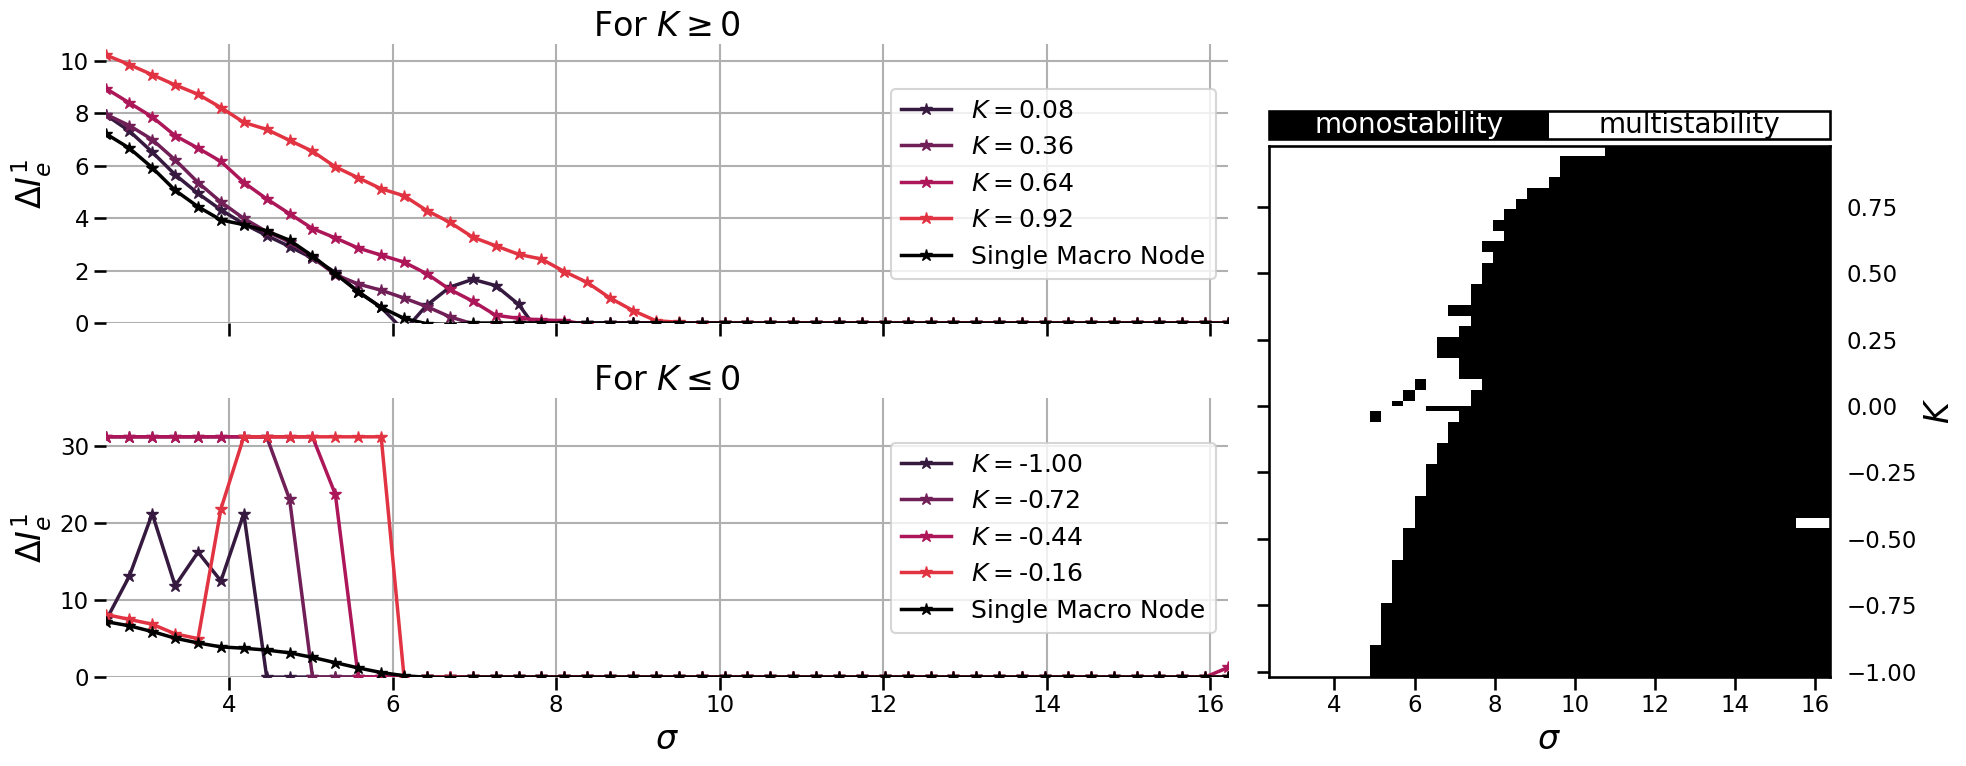

In [18]:
fileName = 'Scene01_MultiStable_DeltaI.pdf'

fig, axs = plt.subplots(2, 2, sharex=True, figsize=(20, 8),  gridspec_kw={'width_ratios':[2,1]})
 
max_ylim = 0

for pos in ['left', 'top', 'bottom', 'right']:
    axs[0][0].spines[pos].set_visible(False)
    axs[1][0].spines[pos].set_visible(False)
    
for nK in range(0, nKvals, 7):
    if round(K_uniq[nK], 2) == 0 or K_uniq[nK] < 0:
        continue
    max_ylim = max(max_ylim, max(deltaI_arr[nK, :]))
    axs[0][0].plot(sigma_uniq, smooth(deltaI_arr[nK, :], nWindow=7, polyOrder=3), '-*', linewidth=2.5, label=r"$K = $" + f"{K_uniq[nK]:.2f}")

axs[0][0].plot(sigma_uniq, smooth(Uncoupled, nWindow=7, polyOrder=3), 'k-*', linewidth=2.5, label=r"Single Macro Node")

axs[0][0].set_xlim(sigma_uniq[0], sigma_uniq[-1])
axs[0][0].set_ylim(0, max_ylim)
axs[0][0].set_ylabel(r"$\Delta I^1_e$", fontsize=24)
axs[0][0].legend(loc = 'center right', bbox_to_anchor=(1., 0.5), fontsize=18)
axs[0][0].set_title(r"For $K \geq 0$", fontsize=24)
axs[0][0].grid(True)


max_ylim = 0
for nK in range(0, nKvals, 7):
    if round(K_uniq[nK], 2) == 0 or K_uniq[nK] > 0:
        continue
    max_ylim = max(max_ylim, max(deltaI_arr[nK, :]))
    axs[1][0].plot(sigma_uniq, smooth(deltaI_arr[nK, :], nWindow=3, polyOrder=2), '-*', linewidth=2.5, label=r"$K = $" + f"{K_uniq[nK]:.2f}")

axs[1][0].plot(sigma_uniq, smooth(Uncoupled, nWindow=7, polyOrder=3), 'k-*', linewidth=2.5, label=r"Single Macro Node")

axs[1][0].set_xlim(sigma_uniq[0], sigma_uniq[-1])
axs[1][0].set_ylim(0, max_ylim + 5)
axs[1][0].set_ylabel(r"$\Delta I^1_e$", fontsize=24)
axs[1][0].set_xlabel(r"$\sigma$", fontsize=24)
axs[1][0].legend(loc = 'center right', bbox_to_anchor=(1., 0.5), fontsize=18)
axs[1][0].set_title(r"For $K \leq 0$", fontsize=24)
axs[1][0].grid(True)

gs = axs[0, 1].get_gridspec()
for ax in axs[0:, -1]:
    ax.remove()
axsbig = fig.add_subplot(gs[0:, -1])
axsbig.tick_params(axis='y', which='both', labelleft=False, labelright=True)
axsbig.yaxis.set_label_position("right")

cMap = ListedColormap(["black", "white"])
heatmap = axsbig.pcolormesh(sigma_uniq, K_uniq, encodeDeltaI, cmap=cMap)
cbar = fig.colorbar(heatmap, ax=axsbig, location='top', pad=0.01)

cbar.ax.get_xaxis().set_ticks([])
cbar.ax.text(0.75, .5 , r"multistability", ha='center', va='center', fontsize=20)
cbar.ax.text(0.25, 0.5 , r"monostability", c = 'w', ha='center', va='center', fontsize=20)
# cbar.ax.set_position((1, 0.2, 0.1, 3.5))
axsbig.set_ylabel(r"$K$", fontsize=24); axsbig.set_xlabel(r"$\sigma$", fontsize=24)

# fig.suptitle(f"Multi-stability region spread with heterogeneity\n" + r"(Change in $I^1_e$ for fixed $K$ values)")
plt.tight_layout()

plt.savefig(os.path.join(save_dir, fileName), bbox_inches='tight')
plt.show()

In [19]:
plt.figure(figsize=(10, 8))
cMap = ListedColormap(["black", "white"])
heatmap = axsbig.pcolormesh(sigma_uniq, K_uniq, encodeDeltaI, cmap=cMap)
cbar = fig.colorbar(heatmap, ax=axsbig, location='top', pad=0.01)

cbar.ax.get_xaxis().set_ticks([])
cbar.ax.text(0.75, .5 , r"multistability", ha='center', va='center', fontsize=20)
cbar.ax.text(0.25, 0.5 , r"monostability", c = 'w', ha='center', va='center', fontsize=20)
# cbar.ax.set_position((1, 0.2, 0.1, 3.5))
axsbig.set_ylabel(r"$K$", fontsize=24); axsbig.set_xlabel(r"$\sigma$", fontsize=24)

# fig.suptitle(f"Multi-stability region spread with heterogeneity\n" + r"(Change in $I^1_e$ for fixed $K$ values)")
plt.tight_layout()

plt.savefig(os.path.join(save_dir, fileName), bbox_inches='tight')
plt.show()

<Figure size 1000x800 with 0 Axes>

Text(0.5, 1.0, 'Multi-stability region spread with heterogeneity \n(# of Multi-stable regions for fixed $ K$ values)')

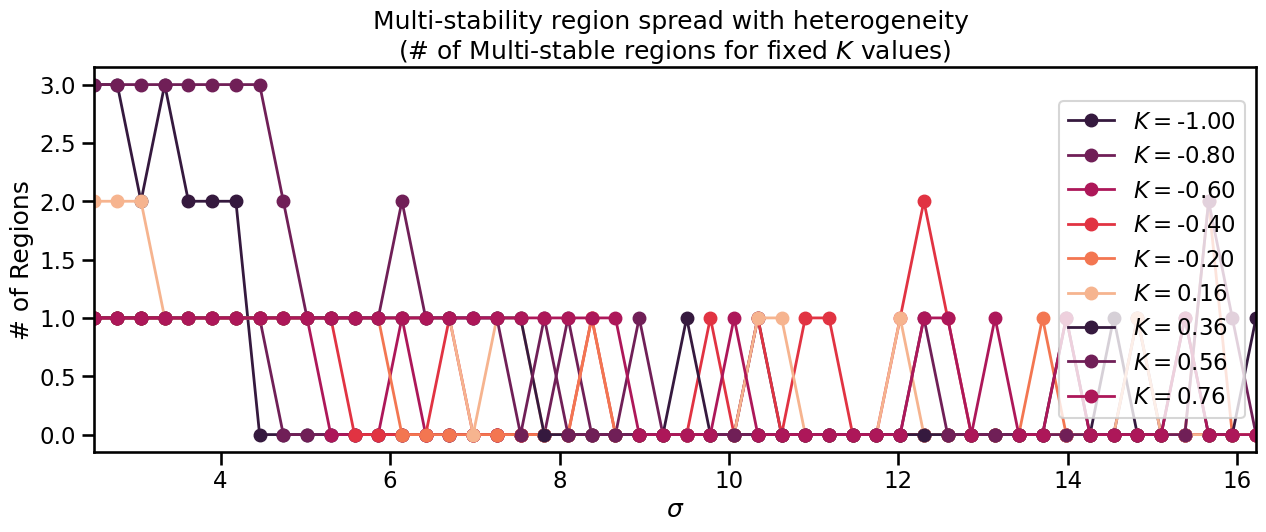

In [20]:
plt.figure(figsize=(15, 5))

for nK in range(0, nKvals - 1, 5):
    if round(K_uniq[nK], 2) == 0:
        continue
    plt.plot(sigma_uniq, MultiI[nK, :], '-o', linewidth=2.0, label=r"$K = $" + f"{K_uniq[nK]:.2f}")

plt.xlim(sigma_uniq[0], sigma_uniq[-1])
plt.xlabel(r"$\sigma$")
plt.ylabel(r"# of Regions")
plt.legend(loc='center right')
plt.title("Multi-stability region spread with heterogeneity \n" +\
          r"(# of Multi-stable regions for fixed $ K$ values)")

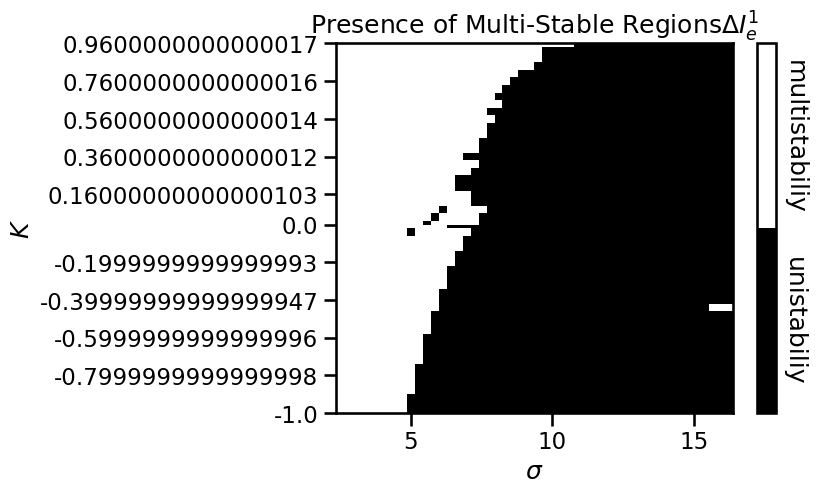

In [21]:
fileName = 'Scene01_MultiStable_DeltaI_HeatMap.png'
smoothDeltI = deepcopy(deltaI_arr)
cMap = ListedColormap(["black", "white"])

for nI in range(nIvals):
    smoothDeltI[nI, :] = smooth(deltaI_arr[nI, :], nWindow=7, polyOrder=3)

encodeDeltaI = deepcopy(smoothDeltI)
encodeDeltaI[encodeDeltaI > 0.000] = 1
encodeDeltaI[encodeDeltaI <= 0.000] = 0

heatmap = plt.pcolormesh(sigma_uniq, K_uniq, encodeDeltaI, cmap=cMap)
cbar = plt.colorbar(heatmap)

cbar.ax.get_yaxis().set_ticks([])
cbar.ax.text(2, .25 , r"unistabiliy", rotation=270, ha='center', va='center')
cbar.ax.text(2, .75 , r"multistabiliy", rotation=270, ha='center', va='center')
plt.xlabel(r"$\sigma$")
plt.ylabel(r"$K$"); plt.ylim(K_uniq[0], K_uniq[-1])
plt.yticks(K_uniq[0 :: 5], K_uniq[0 :: 5])
plt.title("Presence of Multi-Stable Regions" + r"$\Delta I^1_e$")

plt.savefig(os.path.join(save_dir, fileName), dpi=600, bbox_inches='tight')

In [30]:
## Dimension reduction
from sklearn.decomposition import KernelPCA

root_dir = './system_01/results'
type_dir = 'fp'
save_str = datetime.datetime(2024, 2, 10)

load_dir = os.path.join(root_dir, type_dir, f'exp-{save_str.year}-{save_str.month}-{save_str.day}')

In [31]:
filePaths = sorted(glob.glob(os.path.join(load_dir, "*0.pkl")))

# sorting based on sigma value
sigma_lookup = {}
k_lookup = {}

for n, filePath in enumerate(filePaths):
    baseName = os.path.basename(filePath)
    sig_val = float(baseName.split('_')[3])
    k_val = float(baseName.split('_')[-1][:-4])

    if sig_val not in sigma_lookup.keys():
        sigma_lookup[sig_val] = [filePath]
        k_lookup[sig_val] = [k_val]
    else:
        sigma_lookup[sig_val].append(filePath)
        k_lookup[sig_val].append(k_val)
    

for key, vals in k_lookup.items():
    k_vals = np.array(vals)
    ksort = np.argsort(k_vals)

    sigma_lookup[key] = np.array(sigma_lookup[key])[ksort]

sigma_vals = np.array(list(sigma_lookup.keys()))
sigSort = np.argsort(sigma_vals)

filePathsSort = []

for n in sigSort:
    sigma_key = sigma_vals[n]
    filePathsSort += list(sigma_lookup[sigma_key])

filePathsSort = np.array(filePathsSort)

In [47]:
def fpPlot(df, xVar='I', ifSave = False,  figsize=(25, 5), **plotparams):

    xlabel = plotparams.get('4Dxlabel')
    xlow = plotparams.get('xlow')
    xhigh = plotparams.get('xhigh')
    suptitle = plotparams.get('title')
    pathToimg = plotparams.get('path')
    
    plt.figure(figsize=figsize)

    plt.subplot(1, 5, 1)
    plt.scatter(df[xVar], df['ue1'], c=df['FP_types'], marker='.')
    plt.ylabel(r"$u_e^1$", fontsize=24, rotation=0, labelpad=15); plt.xlabel(xlabel, fontsize=24)
    plt.xlim(xlow, xhigh)
    # plt.title("Node (1) | E - population")

    plt.subplot(1, 5, 2)
    plt.scatter(df[xVar], df['ui1'], c=df['FP_types'], marker='.')
    plt.ylabel(r"$u_i^1$", fontsize=24, rotation=0, labelpad=15); plt.xlabel(xlabel, fontsize=24)
    plt.xlim(xlow, xhigh)
    # plt.title("Node (1) | I - population")

    plt.subplot(1, 5, 3)
    plt.scatter(df[xVar], df['ue2'], c=df['FP_types'], marker='.')
    plt.ylabel(r"$u_e^2$", fontsize=24, rotation=0, labelpad=15); plt.xlabel(xlabel, fontsize=24)
    plt.xlim(xlow, xhigh)
    # plt.title("Node (2) | E - population")

    plt.subplot(1, 5, 4)
    plt.scatter(df[xVar], df['ui2'], c=df['FP_types'], marker='.')
    plt.ylabel(r"$u_i^2$", fontsize=24, rotation=0, labelpad=15); plt.xlabel(xlabel, fontsize=24)
    plt.xlim(xlow, xhigh)
    # plt.title("Node (2) | I - population")


    plt.subplot(1, 5, 5)
    plt.scatter(df[xVar], df['U'], c=df['FP_types'], marker='.')
    plt.ylabel(r"$\psi(\mathbf{U})$", fontsize=24, labelpad=15); plt.xlabel(xlabel, fontsize=24)
    plt.xlim(xlow, xhigh)
    # plt.title(r"Network")
    # plt.tick_params(axis='y', which='both', labelleft=False, labelright=False)

    # plt.suptitle(suptitle, fontsize=20)
    plt.tight_layout()

    if ifSave:
        plt.savefig(pathToimg, dpi=600, bbox_inches='tight')
        
    plt.show()

In [48]:
def dimreduction(dataDict, xVar='I', **params):
    dataD = {}
    dataD[xVar] = [x / params.get('gamma') - params.get('i_e2') for x in dataDict['fp_var']]

    for key, val in dataDict['fps'].items():
        dataD[key] = val
    
    dataDF = pd.DataFrame.from_dict(dataD)
    dataDF = dataDF[["ue1","ui1", "ue2", "ui2"]] * params.get('gamma')

    PCA_INIT = KernelPCA(n_components=1, kernel='poly')
    U = PCA_INIT.fit_transform(dataDF)

    dataD['U'] = U.flatten() / params.get('gamma')
    dataD['FP_types'] = dataDict['fp_types']['ue1']

    dataDF = pd.DataFrame.from_dict(dataD)

    return dataDF  

In [49]:
def plot_fp_projections(plot_fps_dict, plot_dict=None, save_dir=None, if_save=False, image_name=None, **opts):
    fig, axs = plt.subplots(2, 2, figsize=plot_dict['fig_size'], sharex=True)
    low_xlim = plot_fps_dict['fp_var'][0]
    high_xlim = plot_fps_dict['fp_var'][-1]

    if plot_dict['var_name'] == 'external stimulus':
        low_xlim = low_xlim / opts.get('gamma') - opts.get('i_e2')
        high_xlim = high_xlim / opts.get('gamma') - opts.get('i_e2')
        plot_fps_dict['fp_var'] = np.array(plot_fps_dict['fp_var']) / opts.get('gamma') - opts.get('i_e2')

    axs[0][0].scatter(plot_fps_dict['fp_var'], plot_fps_dict['fps']['ue1'], marker='.',
                      c=plot_fps_dict['fp_types']['ue1'])
    axs[0][0].set_xlim([low_xlim, high_xlim])
    axs[0][0].set_ylabel(r"$u_e^1$");
    # axs[0][0].set_xlabel(plot_dict['xlabel'])
    axs[0][0].set_title("Node 01 (excitatory)");
    axs[0][0].grid(True)

    axs[0][1].scatter(plot_fps_dict['fp_var'], plot_fps_dict['fps']['ui1'], marker='.',
                      c=plot_fps_dict['fp_types']['ui1'])
    axs[0][1].set_xlim([low_xlim, high_xlim])
    axs[0][1].set_ylabel(r"$u_i^1$");
    # axs[0][1].set_xlabel(plot_dict['xlabel'])
    axs[0][1].set_title("Node 01 (inhibitory)");
    axs[0][1].grid(True)

    axs[1][0].scatter(plot_fps_dict['fp_var'], plot_fps_dict['fps']['ue2'], marker='.',
                      c=plot_fps_dict['fp_types']['ue2'])
    axs[1][0].set_xlim([low_xlim, high_xlim])
    axs[1][0].set_ylabel(r"$u_e^2$");
    # axs[1][0].set_xlabel(plot_dict['xlabel'])
    axs[1][0].set_title("Node 02 (excitatory)");
    axs[1][0].grid(True)

    axs[1][1].scatter(plot_fps_dict['fp_var'], plot_fps_dict['fps']['ui2'], marker='.',
                      c=plot_fps_dict['fp_types']['ui2'])
    axs[1][1].set_xlim([low_xlim, high_xlim])
    axs[1][1].set_ylabel(r"$u_i^2$");
    # axs[1][1].set_xlabel(plot_dict['xlabel'])
    axs[1][1].set_title("Node 02 (inhibitory)");
    axs[1][1].grid(True)

    # fig.suptitle(f"Fixed point evolution with {plot_dict['var_name']}\n" + f"{plot_dict['d_var_str']}")
    fig.supxlabel(r"Modulatory input on active node ($I^1_e$)")
    fig.supxlabel(plot_dict['xlabel'])
    fig.tight_layout()

    if if_save:
        fig.savefig(os.path.join(save_dir, os.path.basename(image_name) + '.png'), dpi = 600, bbox_inches='tight')
    plt.show()

    return

In [50]:
# for filePath in filePathsSort:
#     with open(filePath, 'rb') as file_:
#         DataDict = pickle.load(file_)
    
#     BaseName = os.path.basename(filePath)
#     K = float(BaseName.split('_')[-1][:-4])
#     Sig = float(BaseName.split('_')[3])
    
#     if K != 0.8:
#         continue
    
#     plot_dict = {'fig_size': (10, 8), 'xlabel': r"$I^1_e$", 'var_name': 'external stimulus'}
#     file_str_k = f"scenario_1_sigma_{Sig:.3f}_K_{K:.3f}"

#     plot_fp_projections(DataDict, plot_dict=plot_dict, save_dir=load_dir, if_save=True, image_name=file_str_k, **params)

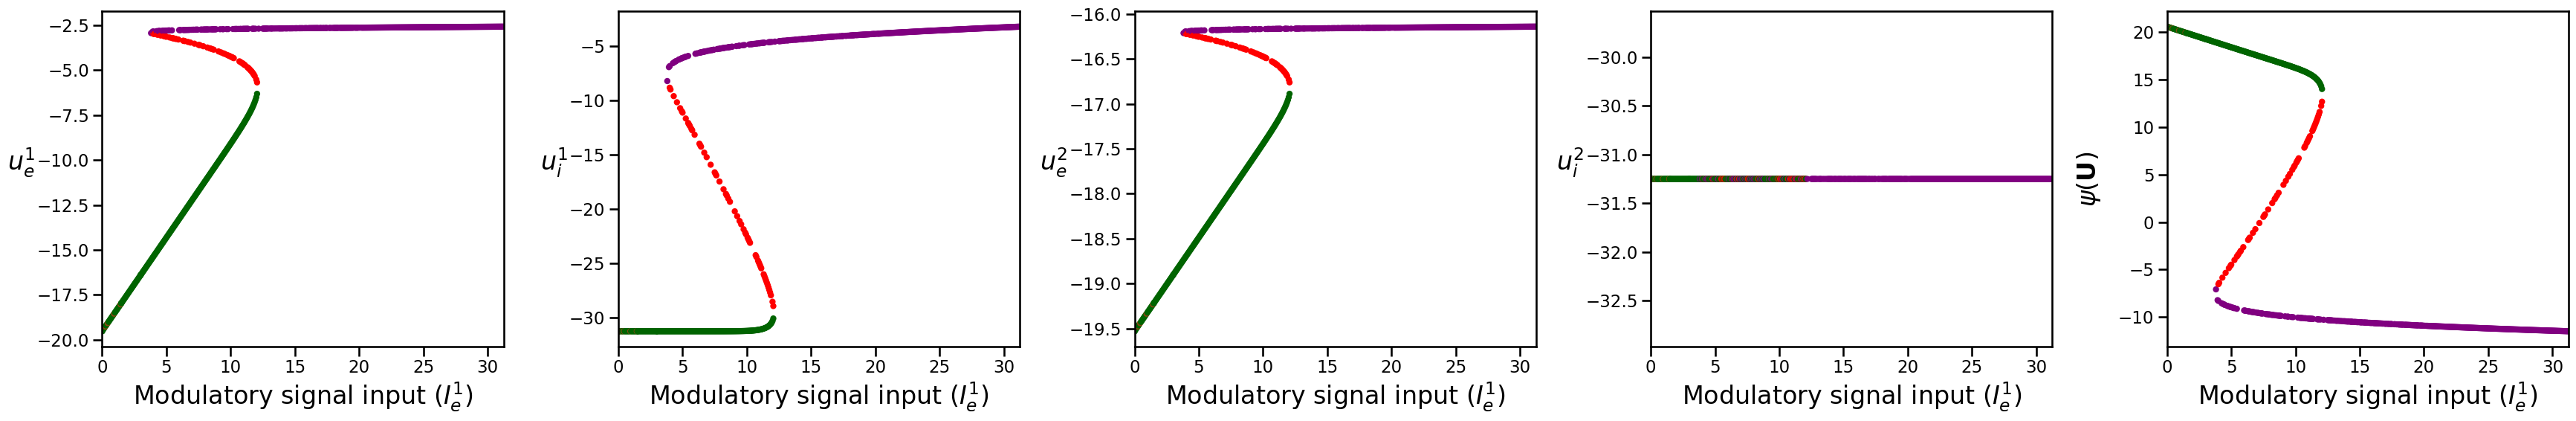

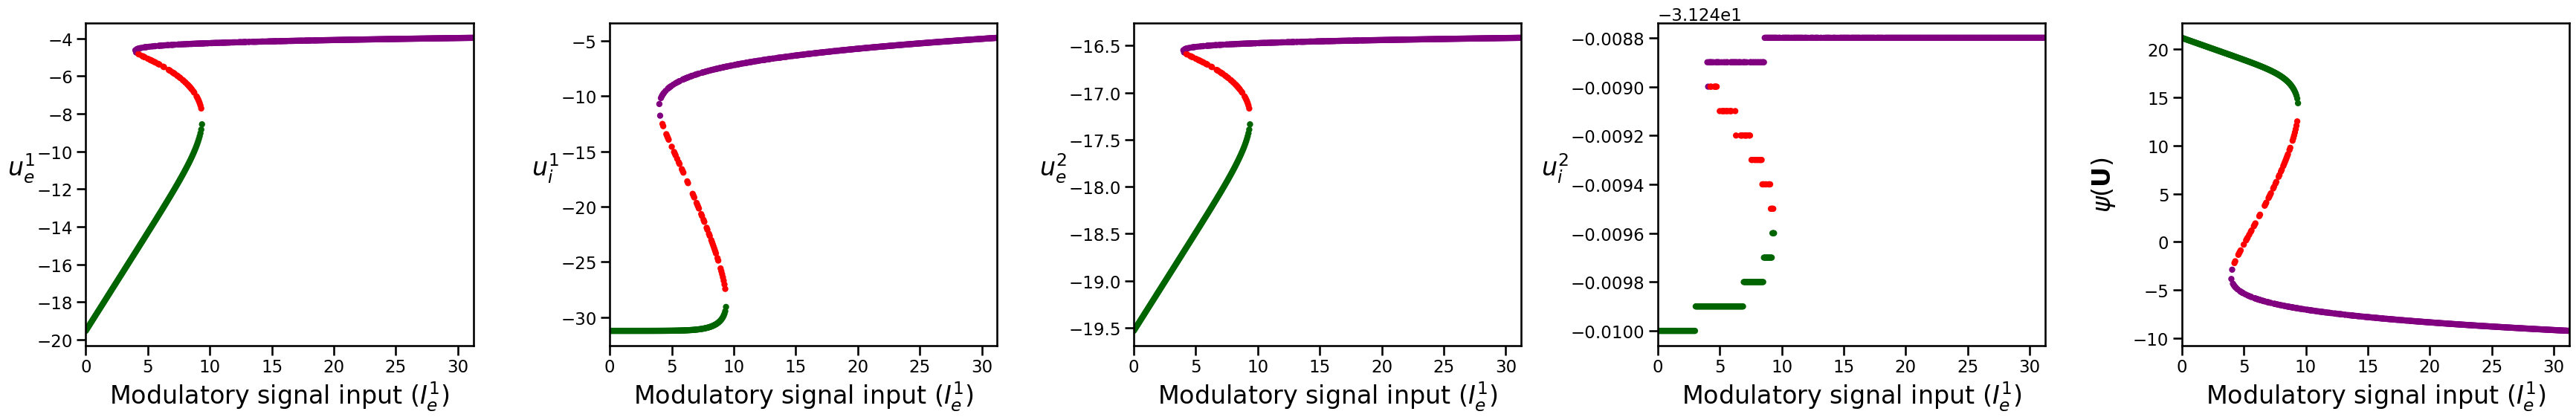

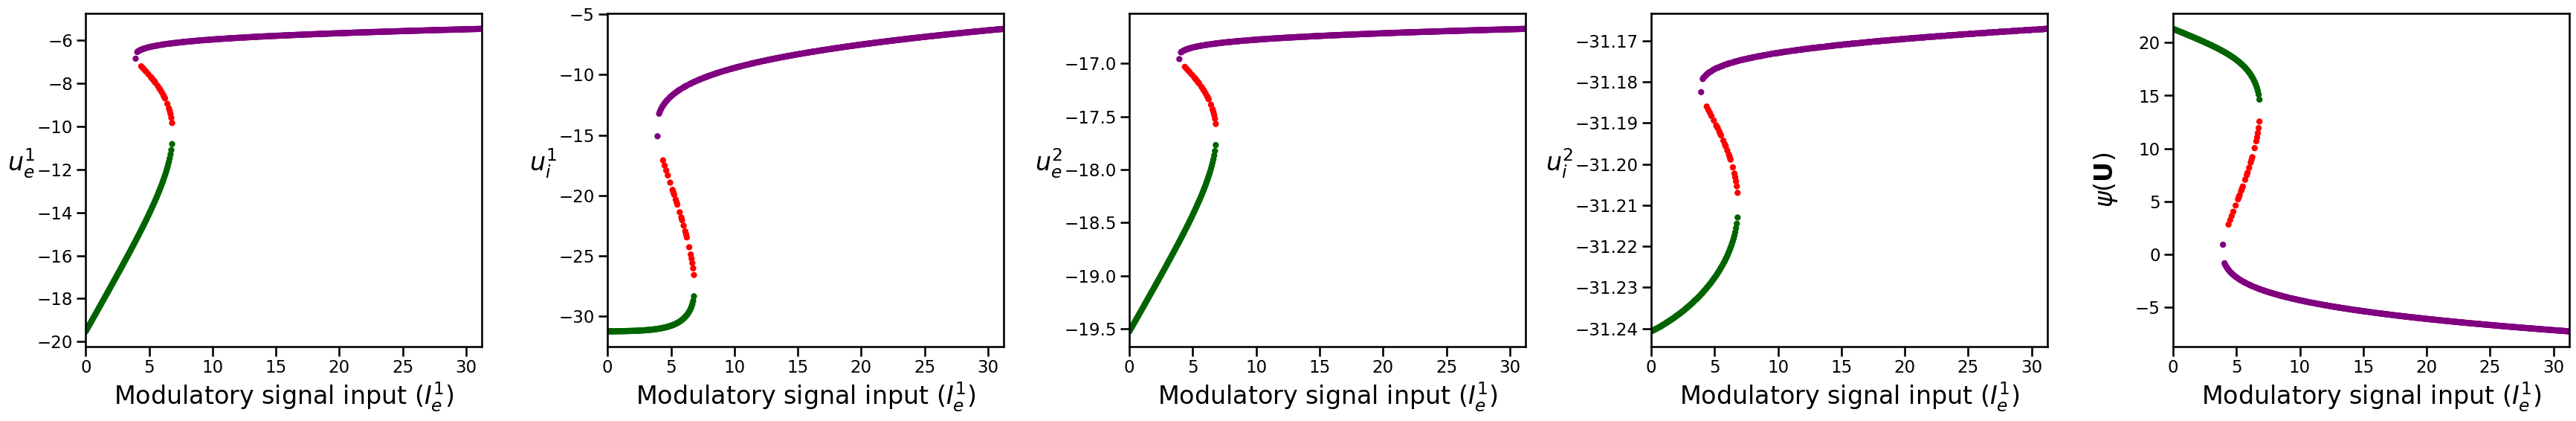

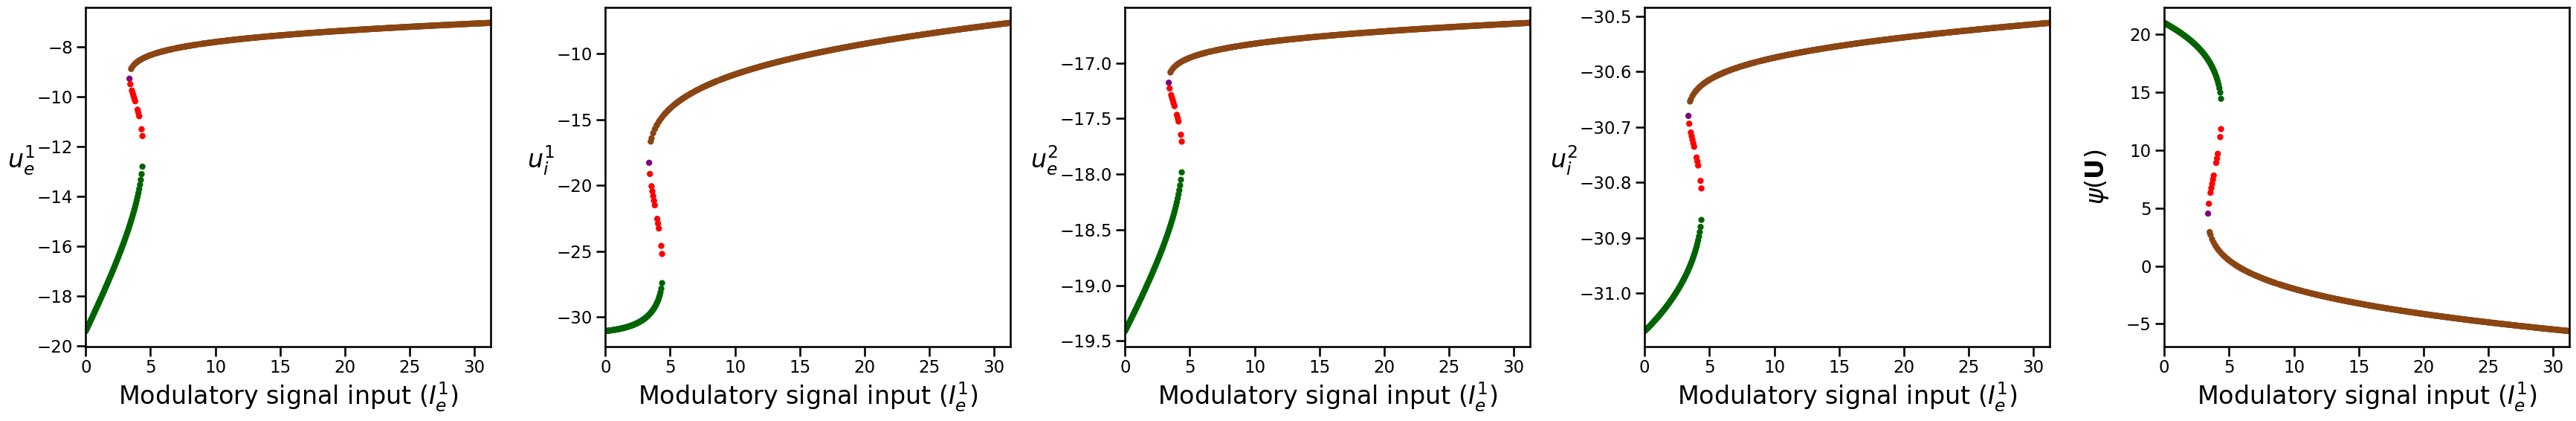

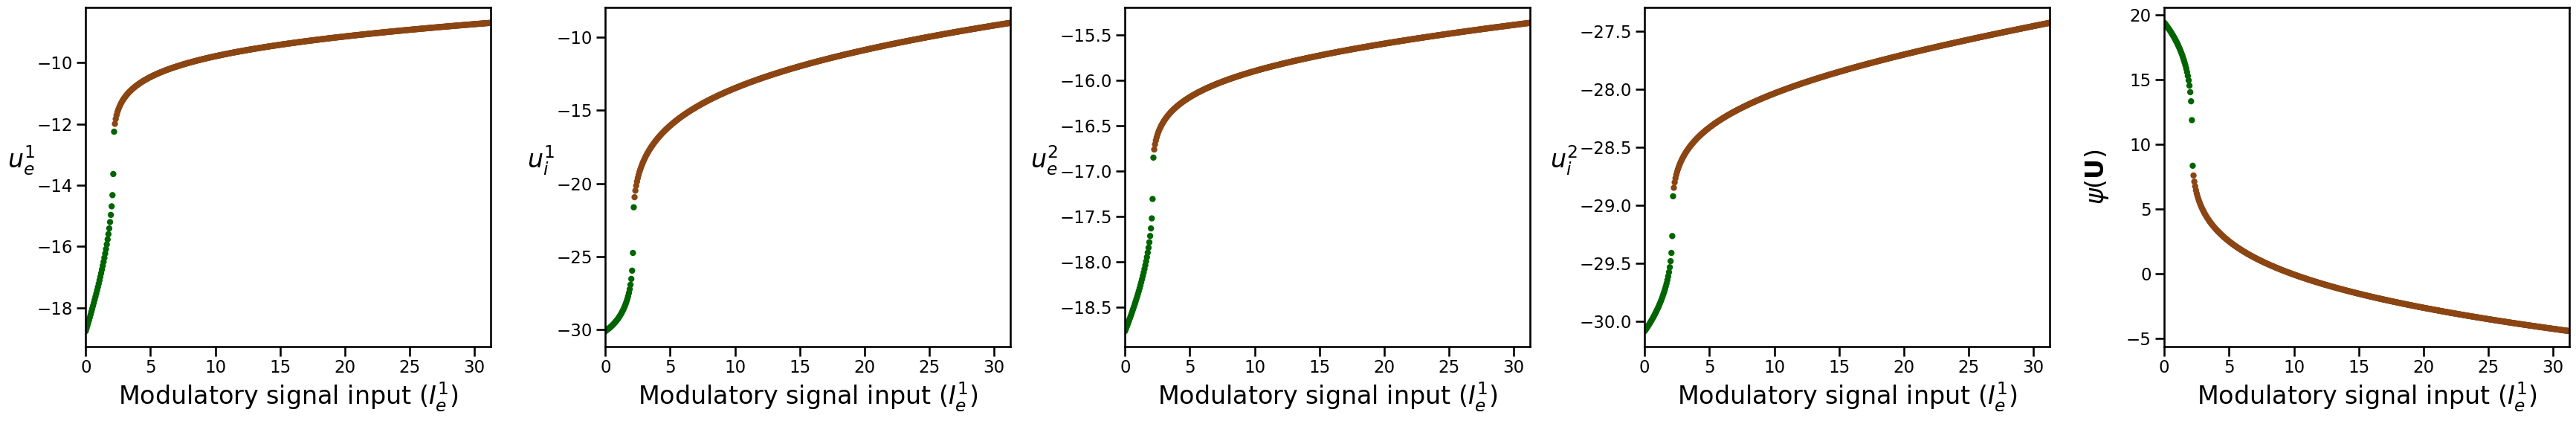

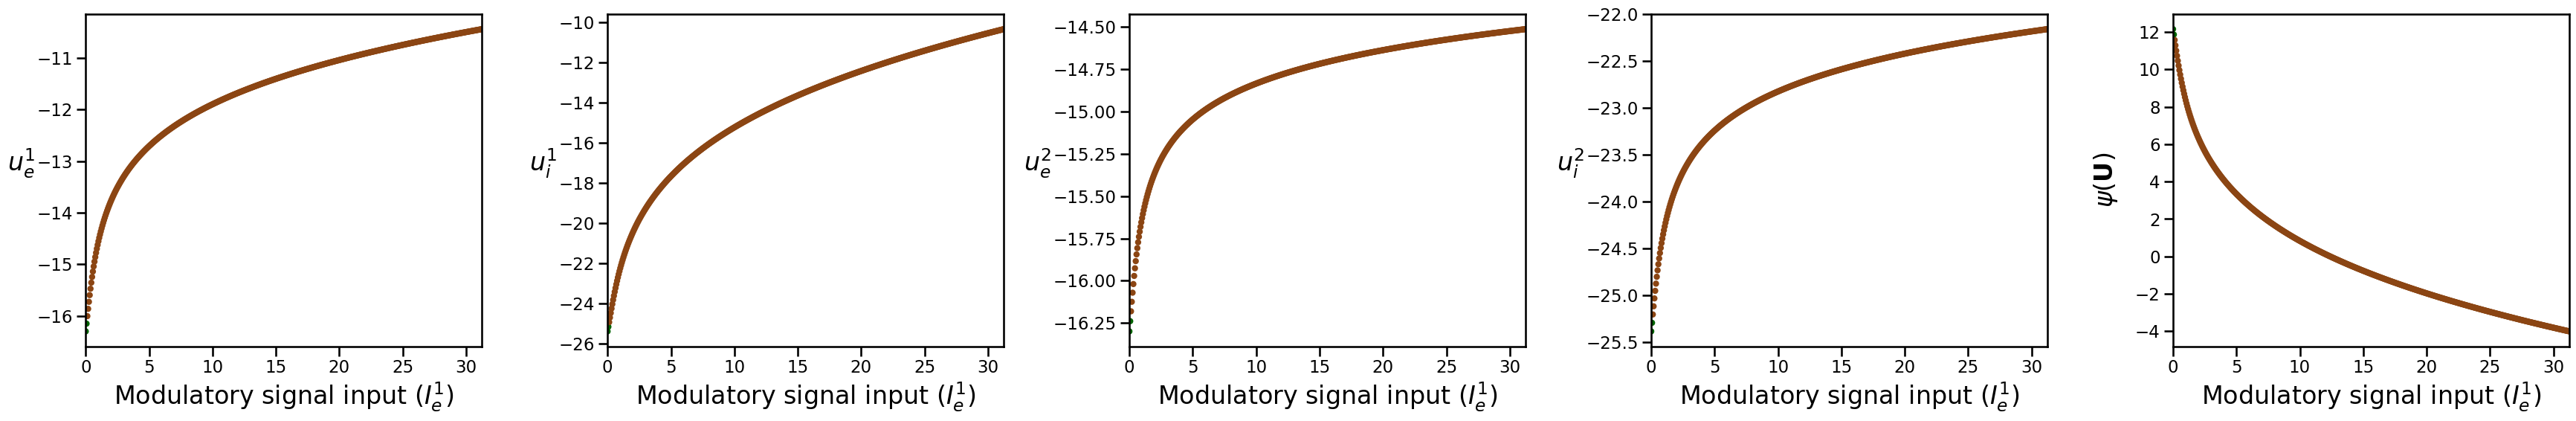

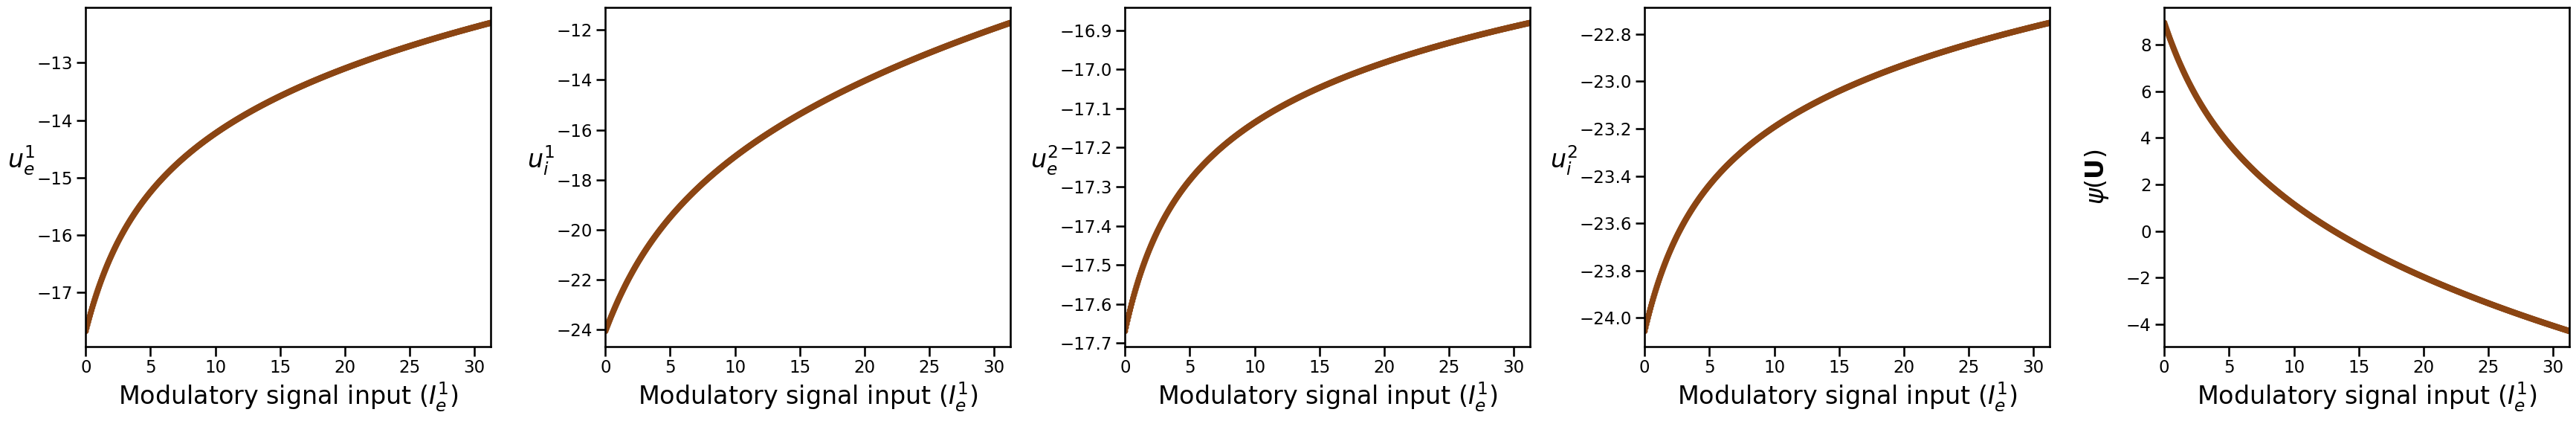

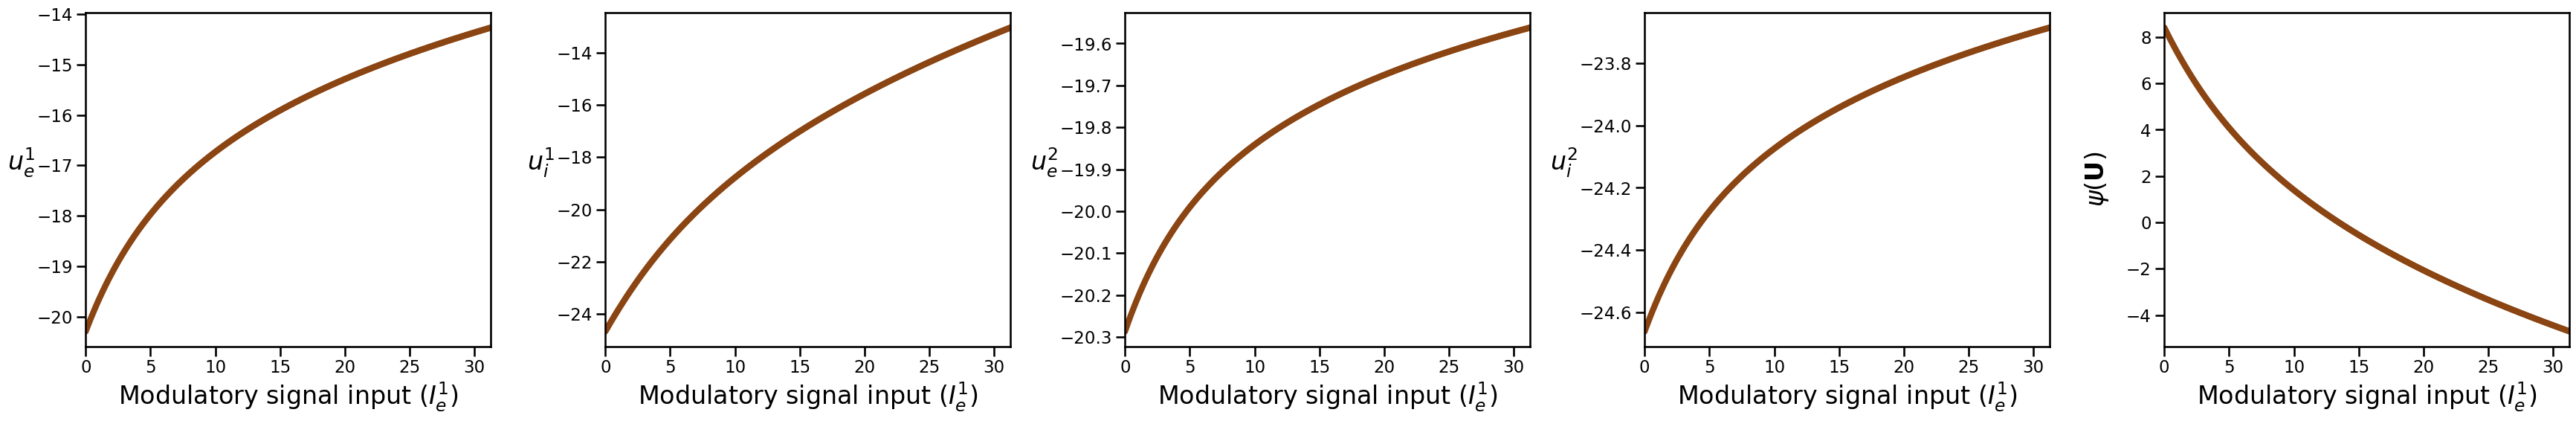

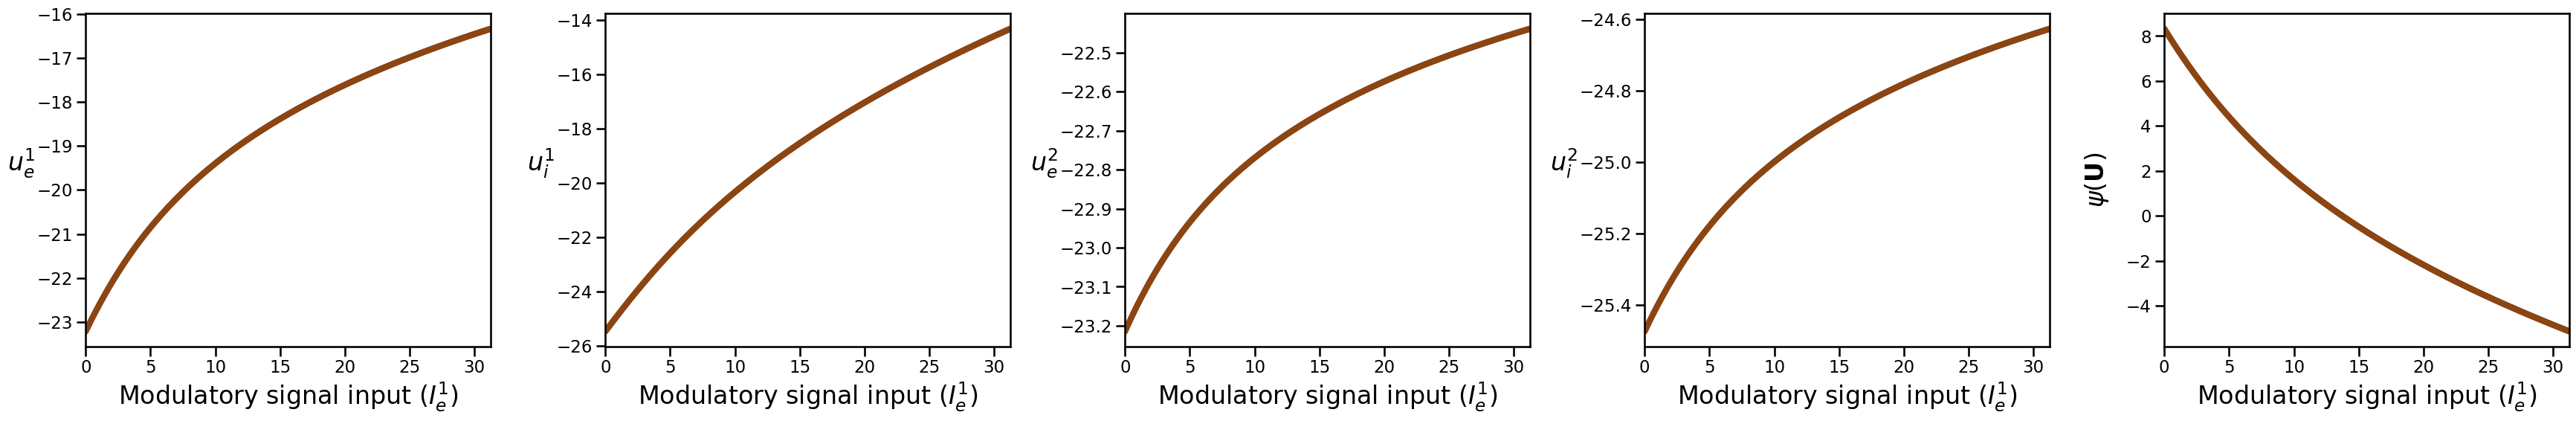

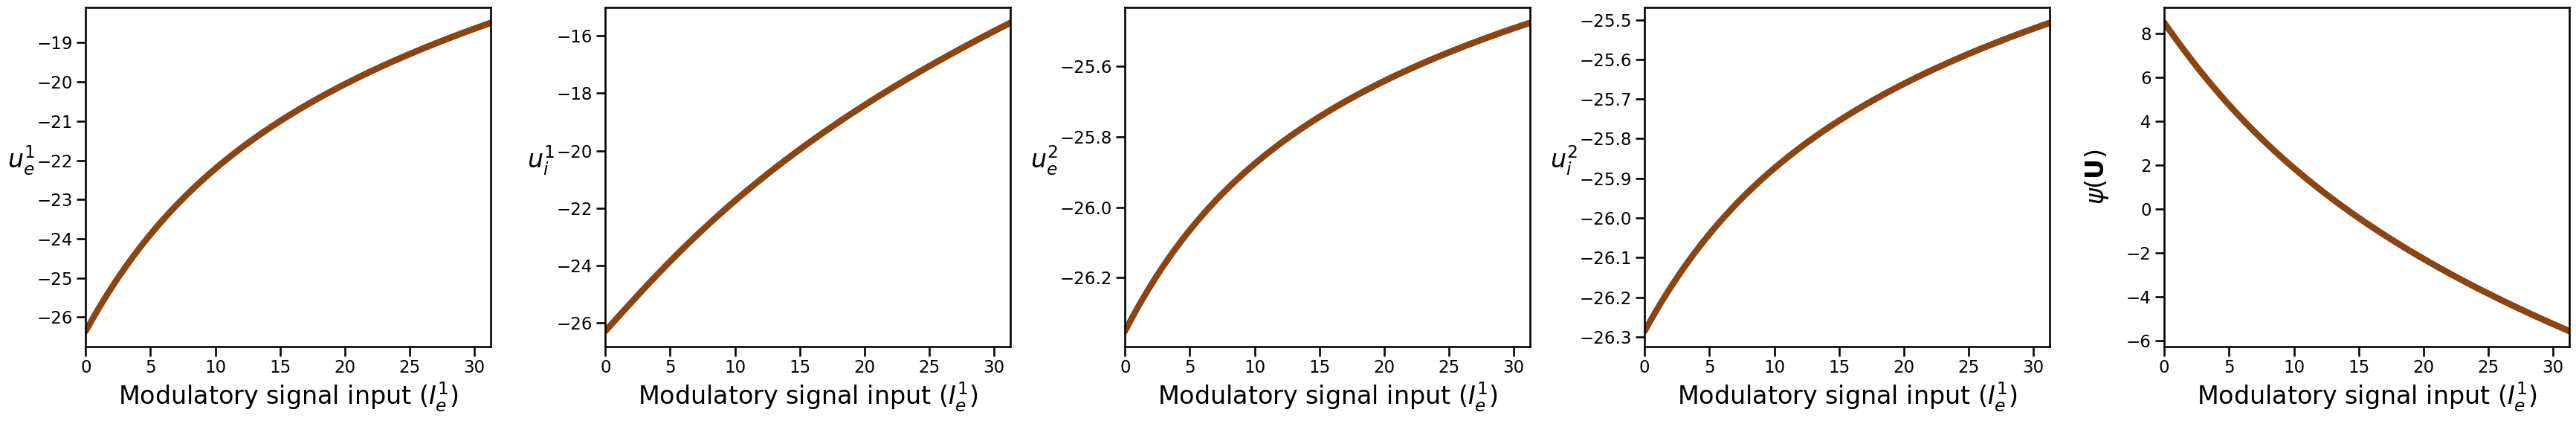

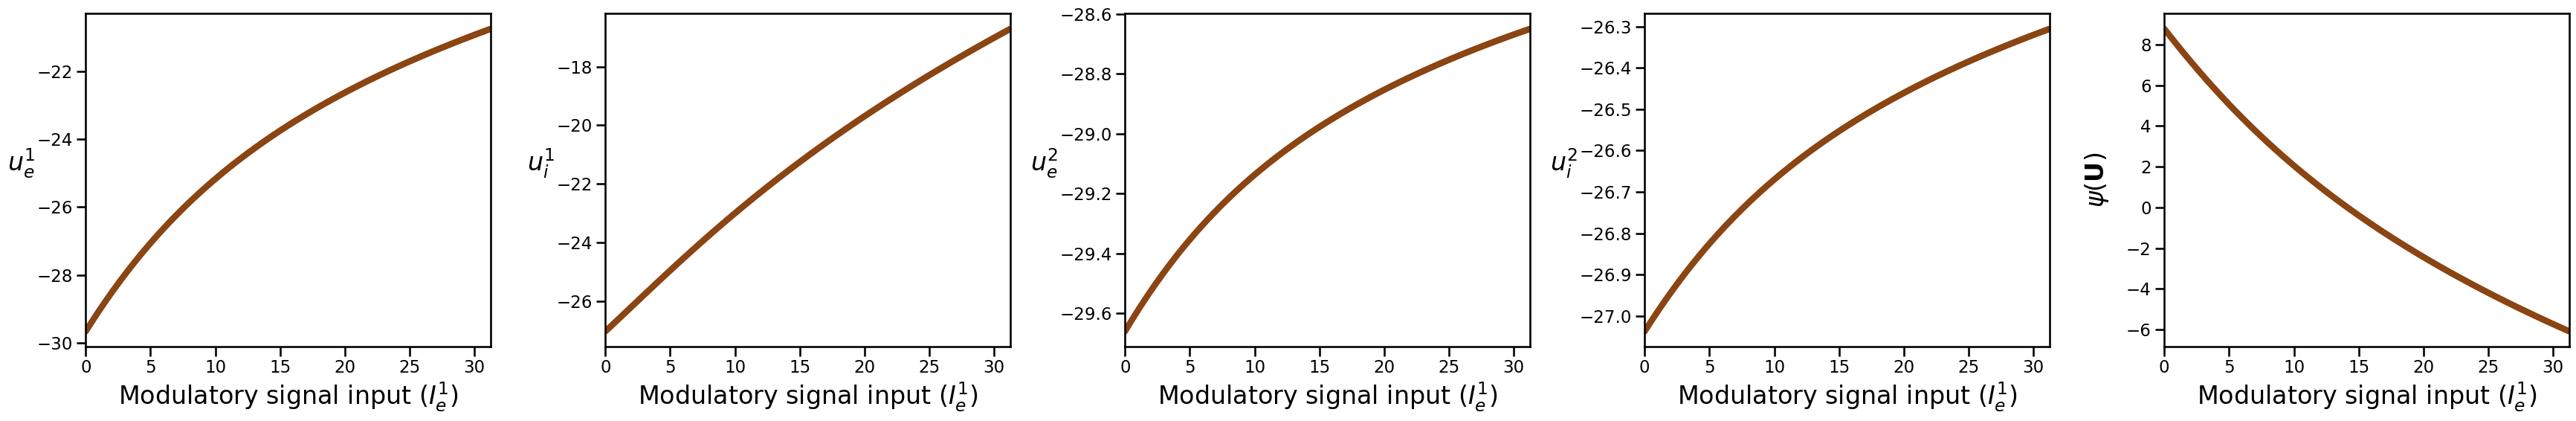

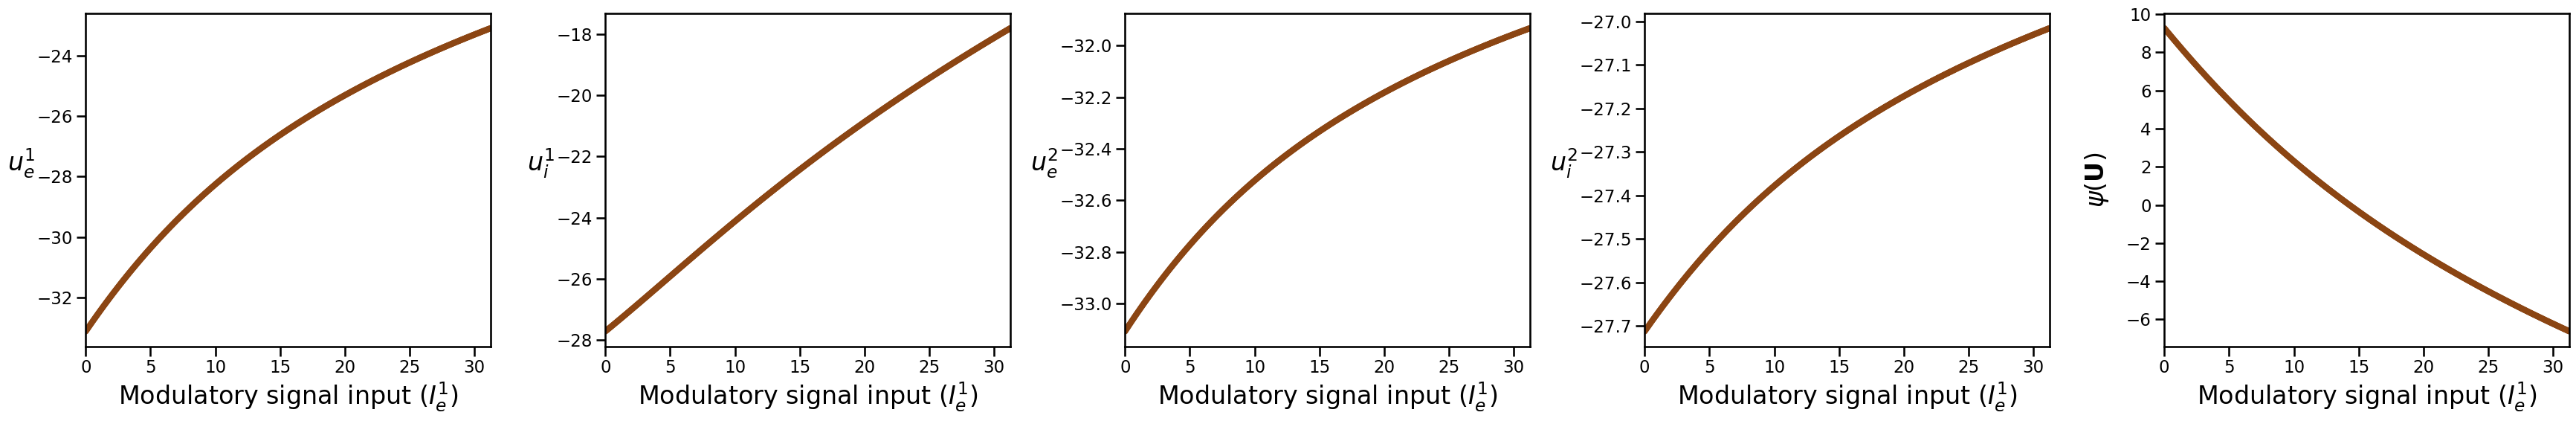

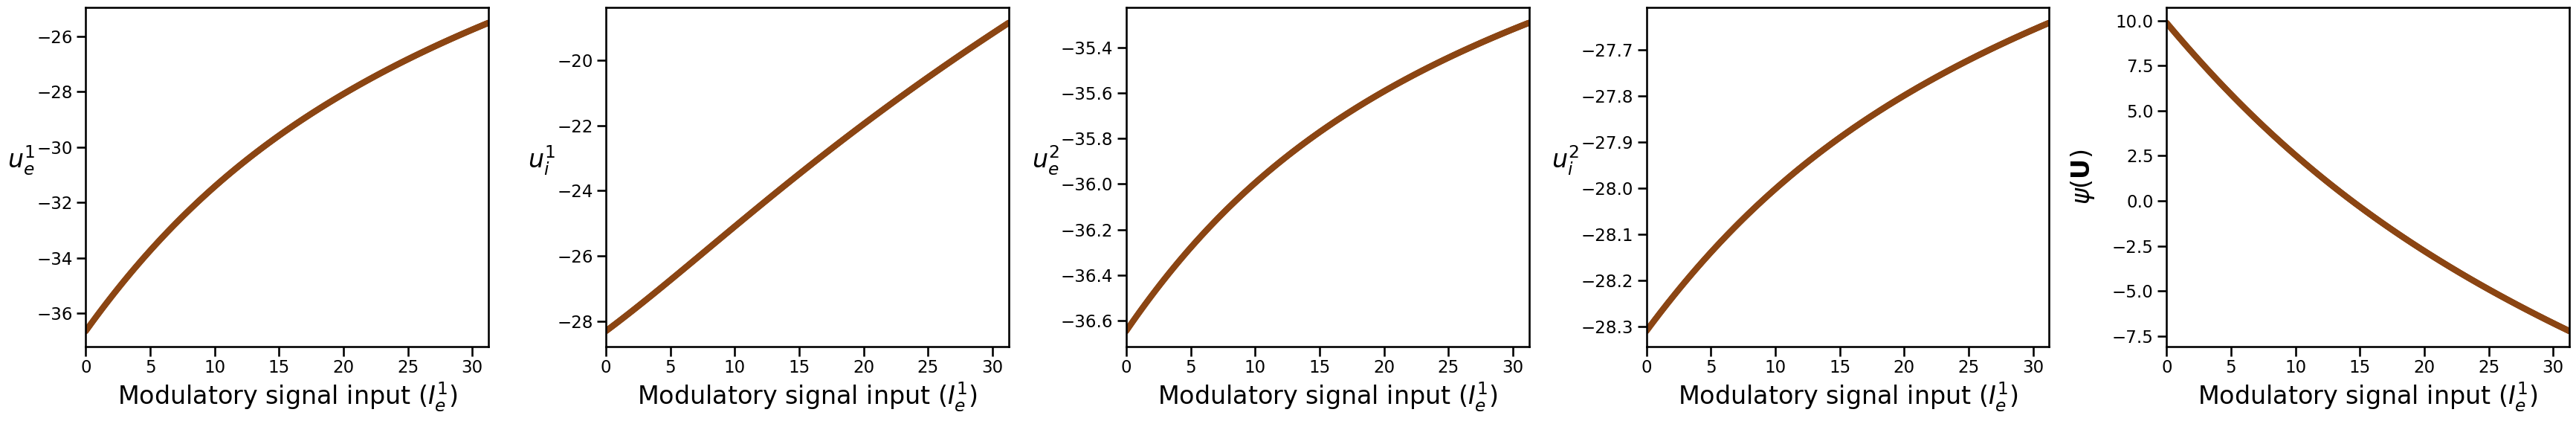

In [52]:
for filePath in filePathsSort:
    with open(filePath, 'rb') as file_:
        DataDict = pickle.load(file_)
    
    BaseName = os.path.basename(filePath)
    K = float(BaseName.split('_')[-1][:-4])
    Sig = float(BaseName.split('_')[3])

    if K != 0.2:
        continue
    DF = dimreduction(DataDict, xVar='I', **params)

    plot_dict = {
                '4Dxlabel': r"Modulatory signal input ($I^1_e$)",
                'xlow': min(DataDict['fp_var']) / params['gamma'] - params['i_e2'],
                'xhigh': max(DataDict['fp_var']) / params['gamma'] - params['i_e2'],
                'title': r"$\sigma$ = " + f"{Sig:.3f} " + r"$K$ = " + f"{K:.2f}",
                'path': f"./results/thesis/fp/FPRedcution_K_{K:.2f}_Sig_{Sig:.3f}.jpg"
    }
    fpPlot(df=DF, xVar='I', ifSave = True,  figsize=(35, 6), **plot_dict)